<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 4. Семинар 2.
# AR, MA, ARMA: как устроены процессы

Семинар 1 закончился на том, что мы умеем превращать нестационарный ряд в
стационарный и знаем, сколько разностей для этого взяли. То есть букву
**$d$** в ARIMA($p$, $d$, $q$) мы уже получили.

Осталось две буквы. Сегодня мы разберём **кирпичи**, из которых собрана
модель для стационарного остатка:

* **MA($q$)** — «скользящее среднее»: ряд как взвешенная сумма последних
  $q$ случайных толчков;
* **AR($p$)** — «авторегрессия»: ряд как функция от собственного прошлого;
* **ARMA($p$, $q$)** — и то и другое одновременно.

🔍 Обратите внимание: сегодня мы **почти не вызываем `.fit()`**. Мы
генерируем ряды с известными параметрами и смотрим, как эти параметры
видны на картинках. Это принципиально: чтобы в ноутбуке `03` определять
порядок модели по коррелограмме, надо сначала запомнить, как выглядит
коррелограмма модели с известным порядком.

> 🔑 **Главная мысль ноутбука.** У AR и MA есть условия — **стационарность**
> и **обратимость**. Это не формальность из учебника: оба условия —
> утверждения о том, где лежат корни некоторого многочлена, и оба
> **видны на картинке**. Если условие нарушено, модель либо не имеет
> смысла, либо неотличима от своего «правильного» двойника.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Обозначения: белый шум, лаг-оператор, соглашения о знаках в `statsmodels` |
| 1 | MA($q$): как выглядит и почему ACF обрывается ровно на лаге $q$ |
| 2 | Обратимость MA: два разных $\theta$ дают одну ACF — какой выбирают и почему |
| 3 | AR($p$): почему PACF обрывается на лаге $p$ и что такое условие стационарности |
| 4 | MA($\infty$) и AR($\infty$): AR и MA — это два языка для одного и того же |
| 5 | ARMA($p$, $q$): почему ни ACF, ни PACF не обрываются |
| 6 | Роль константы: почему `const` в `summary()` — не то, что вы думаете |
| 7 | Как выглядят долгосрочные прогнозы AR, MA, ARMA и ARIMA |



In [3]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scipy.signal import find_peaks

import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess, arma_acf, arma_pacf, arma2ma, arma2ar
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from utils import tsdisplay

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100

print("statsmodels:", sm.__version__)

statsmodels: 0.14.6


Чтобы все картинки воспроизводились, зафиксируем генератор случайных чисел
один раз и дальше будем передавать его в симуляции явно.

In [4]:
SEED = 20240404
N = 400  # длина всех синтетических рядов по умолчанию


def rng():
    """Свежий генератор с фиксированным зерном — одинаковые шоки во всех примерах."""
    return np.random.default_rng(SEED)

---
# 0. Обозначения: белый шум и лаг-оператор

## 0.1. Белый шум — строительный материал

Всё, что мы сегодня строим, собирается из одного и того же сырья —
**белого шума** $\varepsilon_t$:

$$ \mathbb{E}\varepsilon_t = 0, \qquad \mathrm{Var}(\varepsilon_t) = \sigma^2,
   \qquad \mathrm{Cov}(\varepsilon_t, \varepsilon_s) = 0 \ \text{ при } t \ne s. $$

Содержательно $\varepsilon_t$ — это **новость момента $t$**: та часть
наблюдения, которую нельзя было предсказать из прошлого. В литературе её
так и называют — *innovation*, «инновация». Модели AR и MA отличаются
ровно тем, **как долго живёт новость**.

## 0.2. Лаг-оператор

Чтобы не выписывать длинные суммы, вводят оператор сдвига назад $L$:

$$ L y_t = y_{t-1}, \qquad L^2 y_t = y_{t-2}, \qquad L^k y_t = y_{t-k}. $$

С ним модели записываются компактно. **AR($p$)**:

$$ y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p} + \varepsilon_t
   \quad \Longleftrightarrow \quad
   \underbrace{(1 - \varphi_1 L - \dots - \varphi_p L^p)}_{\varphi(L)}\, y_t = c + \varepsilon_t. $$

**MA($q$)**:

$$ y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
   \quad \Longleftrightarrow \quad
   y_t = c + \underbrace{(1 + \theta_1 L + \dots + \theta_q L^q)}_{\theta(L)}\, \varepsilon_t. $$

**ARMA($p$, $q$)** — оба многочлена сразу: $\varphi(L)\, y_t = c + \theta(L)\, \varepsilon_t$.

🔑 Многочлены $\varphi(L)$ и $\theta(L)$ — главные герои ноутбука. Почти
все свойства процесса — стационарность, обратимость, наличие циклов,
скорость затухания прогноза — это утверждения о **корнях** этих двух
многочленов.

## 0.3. Соглашение о знаках в `statsmodels` (важно!)

Класс `ArmaProcess` принимает **коэффициенты лаг-многочленов**, а не
коэффициенты уравнения. Отсюда две ловушки:

1. в массивы включается **нулевой лаг** (единица в начале);
2. у AR-части знаки **инвертируются**, потому что в $\varphi(L)$ они стоят
   с минусом.

То есть для AR(1) с $\varphi_1 = 0.7$ надо передать `ar = [1, -0.7]`.
Чтобы каждый раз об этом не думать, есть конструктор `from_coeffs`,
который берёт коэффициенты **уравнения** и делает всё сам. Дальше в
ноутбуке мы пользуемся почти исключительно им.

In [5]:
phi = 0.7

proc_manual = ArmaProcess(ar=np.r_[1, -phi], ma=np.r_[1])   # «сырой» конструктор
proc_easy = ArmaProcess.from_coeffs(arcoefs=[phi], macoefs=[])  # удобный

print("ar-многочлен, ручной способ:  ", proc_manual.arcoefs, proc_manual.ar)
print("ar-многочлен, from_coeffs:    ", proc_easy.arcoefs, proc_easy.ar)
print("процессы совпадают:", np.allclose(proc_manual.ar, proc_easy.ar))

ar-многочлен, ручной способ:   [0.7] [ 1.  -0.7]
ar-многочлен, from_coeffs:     [0.7] [ 1.  -0.7]
процессы совпадают: True


🔍 **Частая ошибка** — передать `ar=[1, 0.7]` вместо
`ar=[1, -0.7]`. Код не упадёт: получится корректный AR(1), но с
$\varphi_1 = -0.7$, то есть с «пилой» вместо плавного ряда. Проверить себя
всегда можно печатью `.arcoefs` — там лежат коэффициенты **уравнения**.

In [6]:
wrong = ArmaProcess(ar=np.r_[1, 0.7], ma=np.r_[1])
print("что мы хотели: phi =", proc_easy.arcoefs)
print("что получили:  phi =", wrong.arcoefs)

что мы хотели: phi = [0.7]
что получили:  phi = [-0.7]


---
# 1. MA($q$): ряд как память о последних $q$ толчках

## 1.1. Определение и смысл

$$ y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q} $$

Читаем буквально: сегодняшнее значение — это сегодняшняя новость плюс
**эхо** последних $q$ новостей. Ключевое слово — $q$: новость, которая
случилась $q+1$ шаг назад, на сегодняшнее значение не влияет **вообще
никак**. У MA-процесса память конечная и «жёстко обрубленная».

🔍 Название «скользящее среднее» здесь сбивает с толку: это не сглаживание
ряда, как `rolling(k).mean()` из семинара 1. Усредняются не наблюдения, а
**ненаблюдаемые ошибки**. Совпадение названий историческое.

**Теорема Вольда** объясняет, почему MA так важен: любой стационарный
процесс (без детерминированной составляющей) представим в виде
бесконечного MA:

$$ y_t = \mu + \sum_{j=0}^{\infty} \psi_j \varepsilon_{t-j}, \qquad \psi_0 = 1. $$

То есть MA($\infty$) — это **универсальный язык** для стационарных рядов.
Конечные MA($q$) и AR($p$) — просто экономные способы задать
последовательность $\psi_j$ немногими числами. К этой мысли мы вернёмся в
разделе 6.

## 1.2. Как выглядят MA-процессы

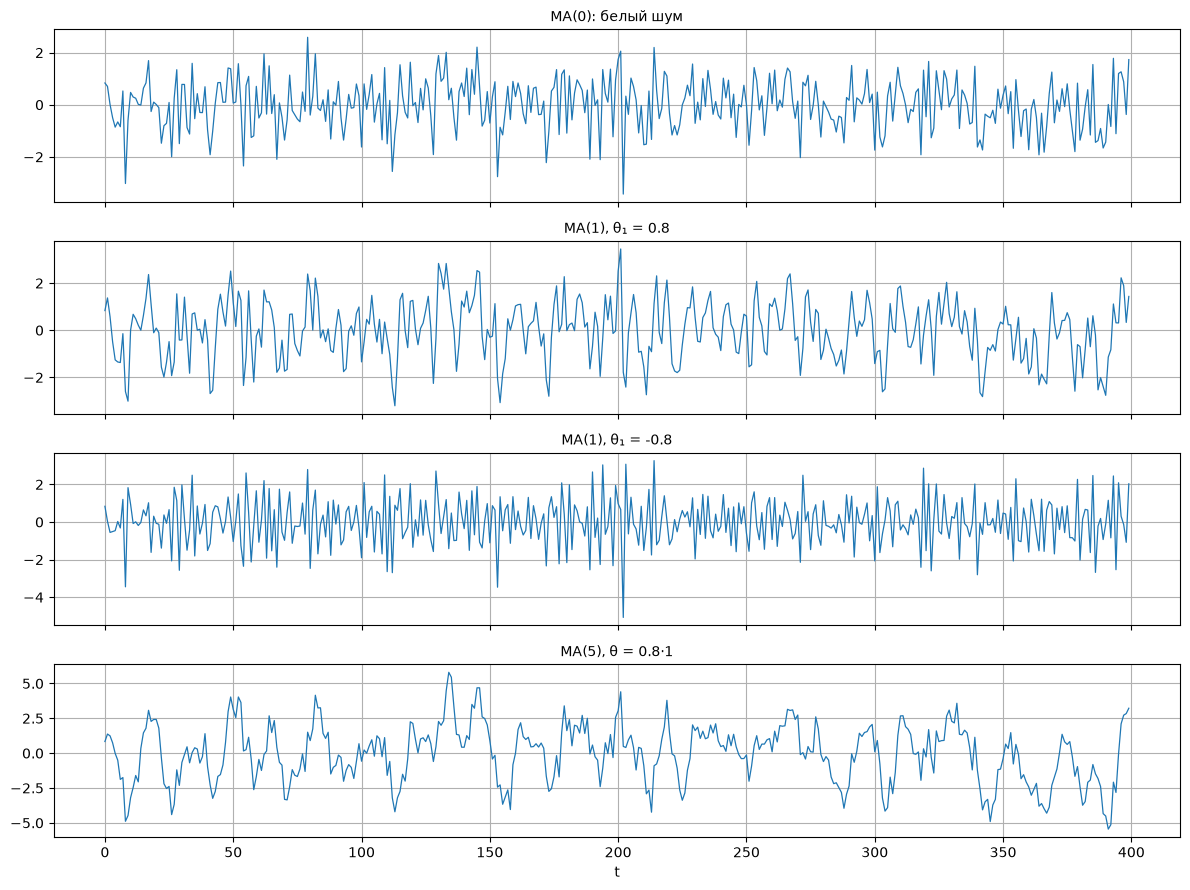

In [7]:
ma_specs = {
    "MA(0): белый шум": [],
    "MA(1), θ₁ = 0.8": [0.8],
    "MA(1), θ₁ = -0.8": [-0.8],
    "MA(5), θ = 0.8·1": [0.8] * 5,
}

ma_samples = {}
for name, thetas in ma_specs.items():
    process = ArmaProcess.from_coeffs(arcoefs=[], macoefs=thetas)
    ma_samples[name] = process.generate_sample(N, distrvs=rng().standard_normal)

fig, axes = plt.subplots(len(ma_samples), 1, figsize=(12, 9), sharex=True)
for ax, (name, y) in zip(axes, ma_samples.items()):
    ax.plot(y, lw=0.9)
    ax.set_title(name, fontsize=10)
axes[-1].set_xlabel("t")
fig.tight_layout()
plt.show()

Разница между рядами есть, но она неочевидна на глаз: все четыре
колеблются вокруг нуля с примерно постоянным размахом. Видно только, что
MA(5) «плавнее» — соседние значения похожи, потому что делят между собой
пять общих шоков.

🔑 **Отсюда мораль всего ноутбука:** порядок процесса на графике самого
ряда практически не читается. Его читают по **коррелограммам**.

## 1.3. Главное свойство: ACF обрывается на лаге $q$

Посчитаем автокорреляцию MA(1) руками. Пусть $\mu = 0$:

$$ \gamma_0 = \mathrm{Var}(y_t) = \sigma^2 (1 + \theta_1^2), \qquad
   \gamma_1 = \mathrm{Cov}(y_t, y_{t-1}) = \theta_1 \sigma^2, $$

потому что в $y_t$ и $y_{t-1}$ есть ровно один общий шок — $\varepsilon_{t-1}$.
А вот в $y_t$ и $y_{t-2}$ общих шоков **нет вообще**, поэтому
$\gamma_2 = \gamma_3 = \dots = 0$. Итого:

$$ \rho_1 = \frac{\theta_1}{1 + \theta_1^2}, \qquad \rho_k = 0 \ \text{ при } k \ge 2. $$

Проверим формулу численно: теоретическая ACF из `arma_acf` против ручного
расчёта и против выборочной ACF нашей симуляции.

In [8]:
theta1 = 0.8
theoretical = arma_acf(ar=np.r_[1], ma=np.r_[1, theta1], lags=6)
sample = sm.tsa.acf(ma_samples["MA(1), θ₁ = 0.8"], nlags=5)

pd.DataFrame(
    {
        "теория (arma_acf)": theoretical,
        "формула вручную": [1.0, theta1 / (1 + theta1**2)] + [0.0] * 4,
        "выборочная ACF": sample,
    },
    index=pd.RangeIndex(0, 6, name="лаг"),
).round(4)

,теория (arma_acf),формула вручную,выборочная ACF
лаг,,,
0,1.0000,1.0000,1.0000
1,0.4878,0.4878,0.5085
2,0.0000,0.0000,0.0586
3,0.0000,0.0000,0.0618
4,0.0000,0.0000,0.0143
5,0.0000,0.0000,-0.0507


Теория и ручная формула совпадают до последнего знака. Выборочная ACF
около $\rho_1$ близка к теоретической, а на лагах $\ge 2$ болтается около
нуля, но не равна нулю точно — это **шум оценивания** на 400 наблюдениях.
Именно поэтому на коррелограммах рисуют доверительные полосы
$\pm 1.96/\sqrt{n}$: столбик внутри полосы считаем нулевым.

🔍 Заметьте: $\rho_1 = \theta_1/(1+\theta_1^2)$, и максимум этой функции по
$\theta_1$ равен $0.5$. **У MA(1) первая автокорреляция физически не может
превысить 0.5 по модулю.** Если вы видите на данных $\rho_1 = 0.8$, MA(1)
не подойдёт ни при каком $\theta_1$ — нужен другой порядок или другая
модель. Это первое из «правил чтения ACF», которые мы соберём в ноутбуке `03`.

Теперь посмотрим на все четыре процесса через `tsdisplay`.

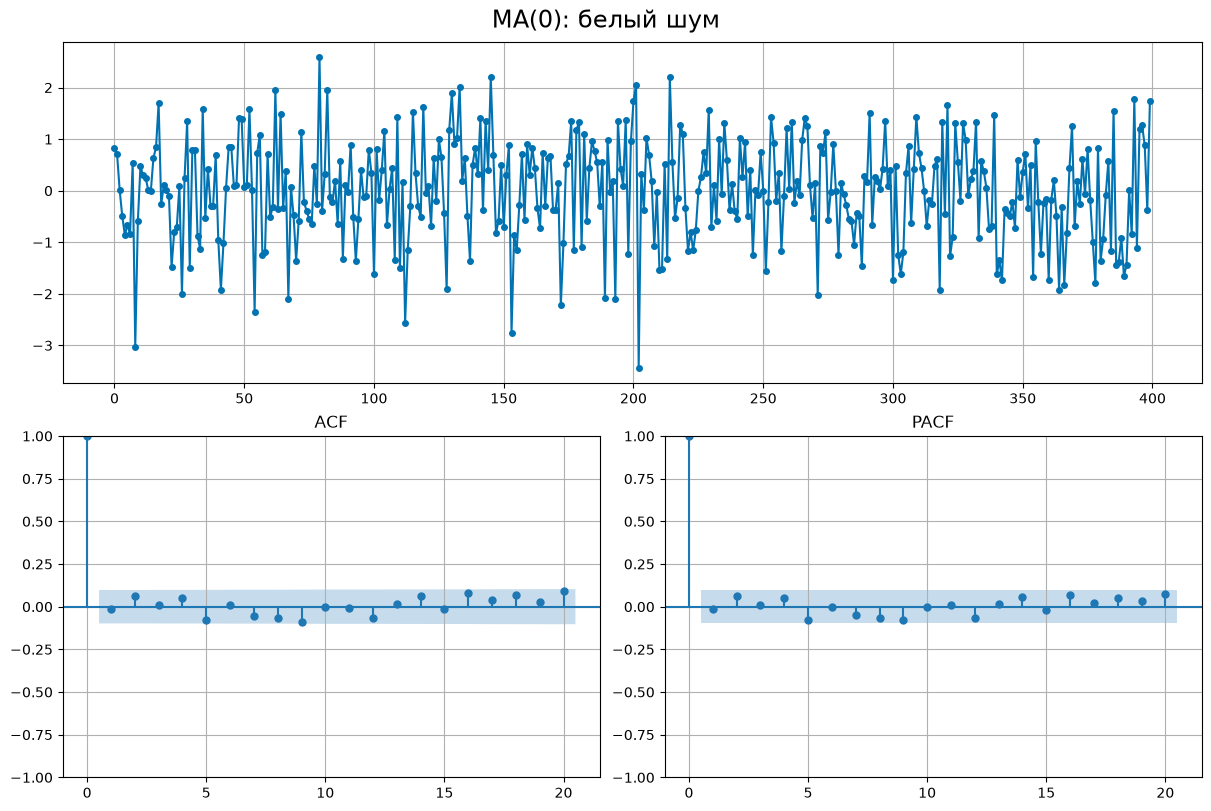

<Figure size 1300x600 with 0 Axes>

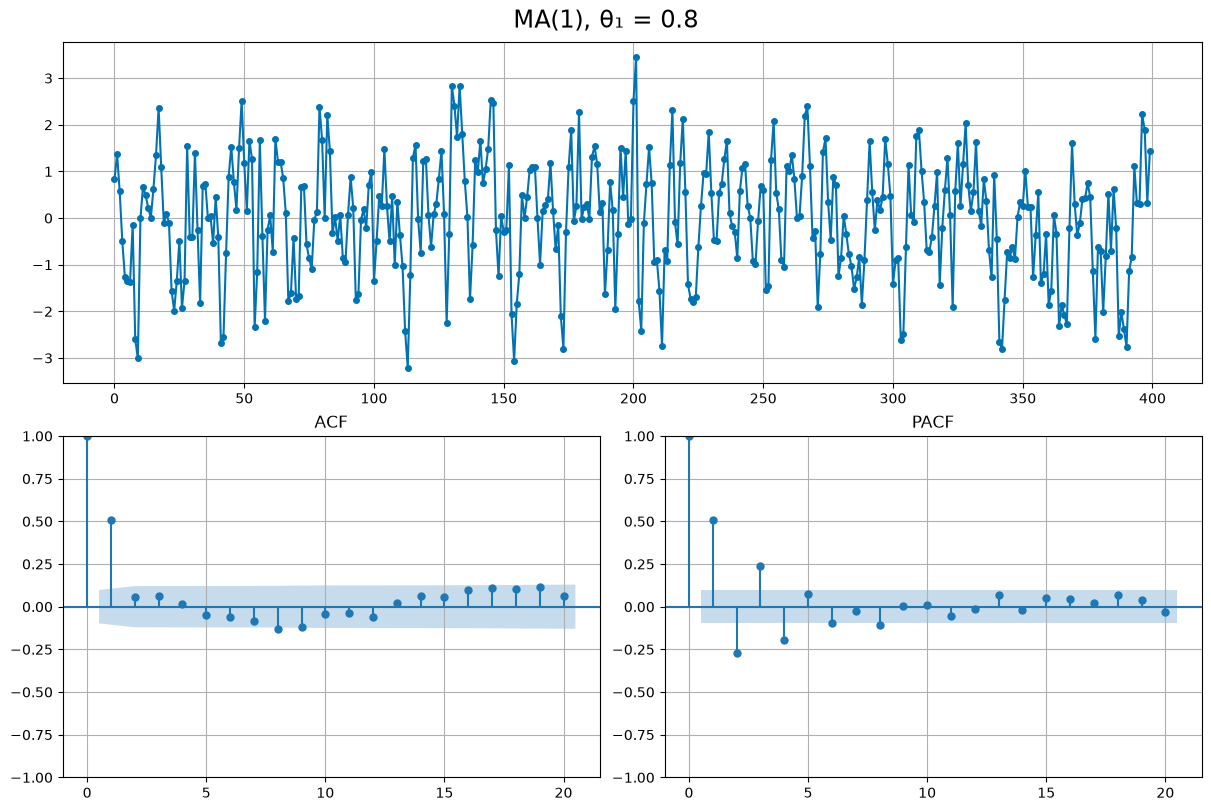

<Figure size 1300x600 with 0 Axes>

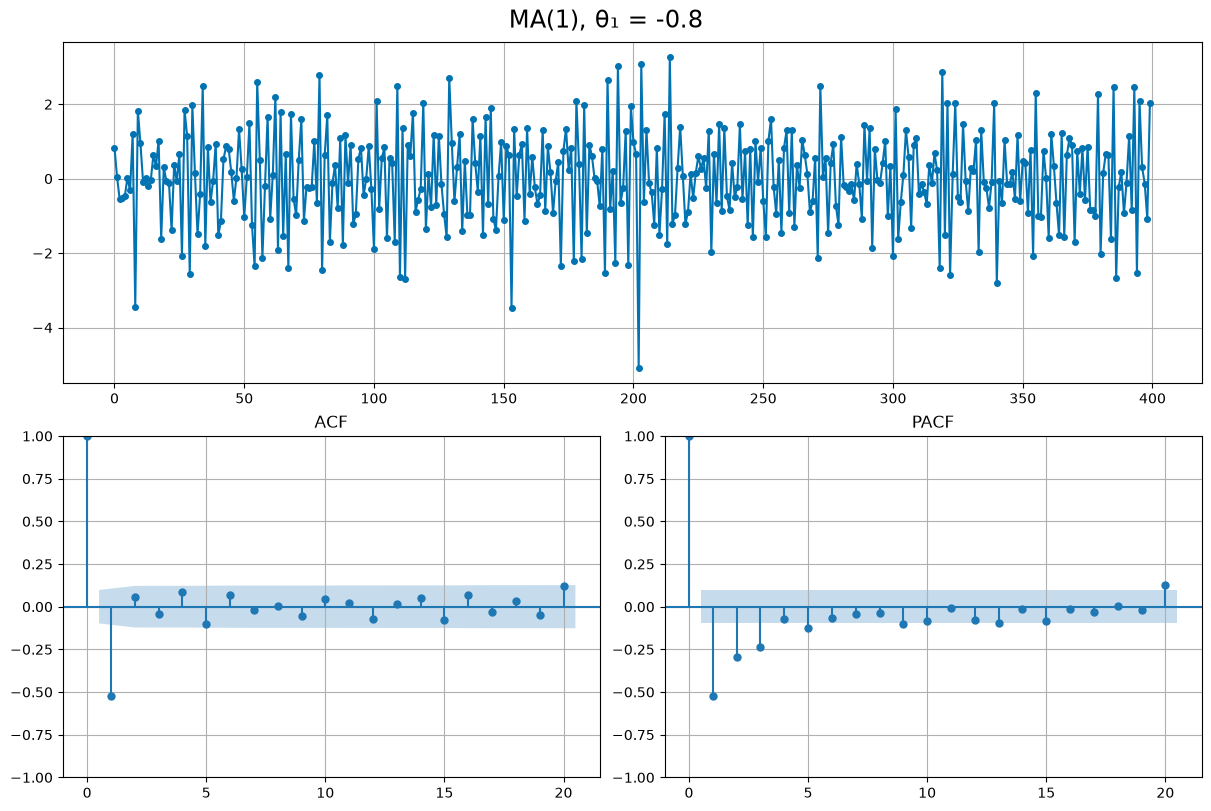

<Figure size 1300x600 with 0 Axes>

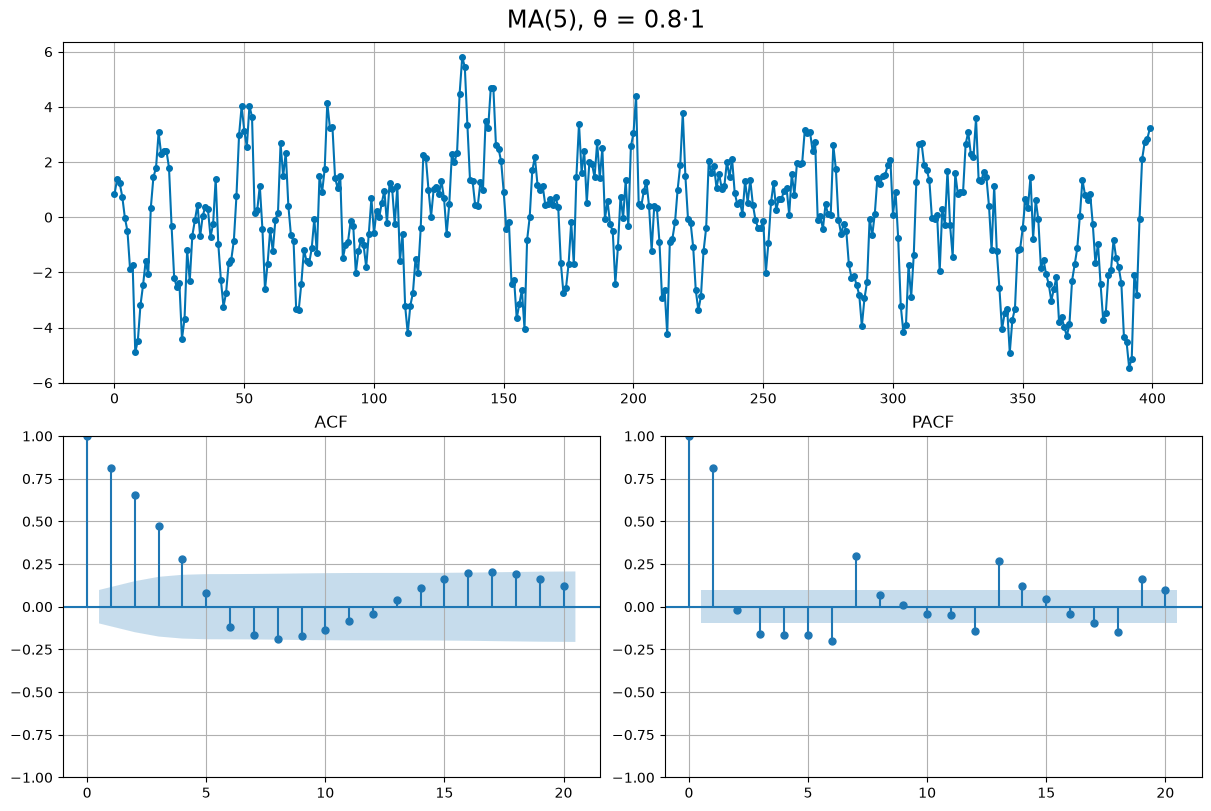

<Figure size 1300x600 with 0 Axes>

In [10]:
for name in ma_samples:
    tsdisplay(pd.Series(ma_samples[name]), lags=20, title=name)
    plt.show()

Читаем панели сверху вниз:

* **MA(0)** — все столбики ACF внутри полосы. Это и есть эталон
  «структуры нет».
* **MA(1), $\theta_1 = 0.8$** — ровно один значимый столбик ACF на лаге 1,
  дальше обрыв. PACF при этом **затухает** — медленно, со сменой знака.
* **MA(1), $\theta_1 = -0.8$** — то же самое, но столбик отрицательный.
* **MA(5)** — значимы лаги с 1 по 5, на лаге 6 обрыв.

> 🔑 **Правило идентификации MA.** Если ACF **обрывается** после лага $q$
> (все следующие столбики внутри полосы), а PACF **затухает** — это MA($q$).

## 1.4. Почему PACF у MA затухает

Симметричный вопрос: почему у MA обрывается именно ACF, а PACF —
«размазана»? Ответ будет полным в разделе 6, а короткая версия такая:
MA($q$) при пересчёте в авторегрессионную форму превращается в
AR($\infty$) — бесконечную авторегрессию с убывающими коэффициентами.
PACF измеряет именно авторегрессионные коэффициенты, поэтому она и не
обрывается.

Сравним выборочную PACF с теоретической — совпадение подтверждает, что
«размазанность» не артефакт симуляции, а свойство процесса.

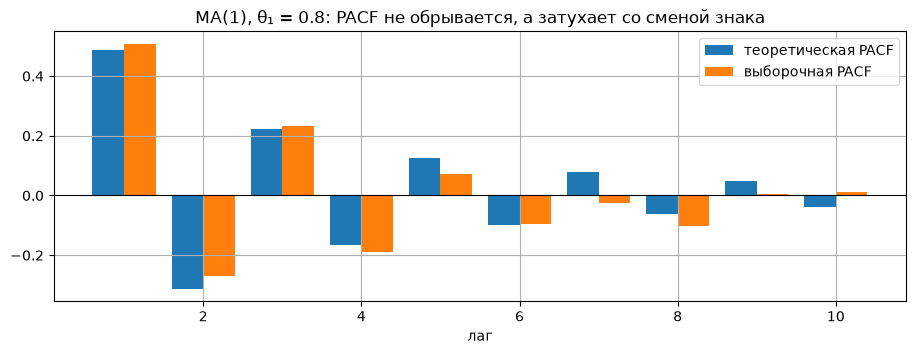

In [11]:
theo_pacf = arma_pacf(ar=np.r_[1], ma=np.r_[1, 0.8], lags=11)
samp_pacf = sm.tsa.pacf(ma_samples["MA(1), θ₁ = 0.8"], nlags=10, method="ywm")

fig, ax = plt.subplots(figsize=(11, 3.5))
lags = np.arange(1, 11)
ax.bar(lags - 0.2, theo_pacf[1:], width=0.4, label="теоретическая PACF")
ax.bar(lags + 0.2, samp_pacf[1:], width=0.4, label="выборочная PACF")
ax.axhline(0, color="k", lw=0.8)
ax.set_title("MA(1), θ₁ = 0.8: PACF не обрывается, а затухает со сменой знака")
ax.set_xlabel("лаг")
ax.legend()
plt.show()

---
# 2. Обратимость MA: почему $\theta$ и $1/\theta$ — это проблема

## 2.1. Неприятное открытие

Подставим в формулу $\rho_1 = \theta_1/(1 + \theta_1^2)$ два значения:
$\theta_1 = 0.5$ и $\theta_1 = 2 = 1/0.5$.

In [12]:
for th in (0.5, 2.0):
    print(f"θ₁ = {th:<4} →  ρ₁ = {th / (1 + th**2):.6f}")

θ₁ = 0.5  →  ρ₁ = 0.400000
θ₁ = 2.0  →  ρ₁ = 0.400000


Одно и то же число. И это не совпадение: замена $\theta_1 \to 1/\theta_1$
не меняет $\rho_1$ вообще никогда, потому что
$\frac{1/\theta}{1 + 1/\theta^2} = \frac{\theta}{\theta^2 + 1}$.

🔑 **Два разных MA(1) неразличимы по автокорреляционной структуре.**
А значит, глядя только на данные, выбрать между ними невозможно —
нужно дополнительное соглашение. Этим соглашением и является
**обратимость**.

Убедимся, что дело не в формуле, а в самих рядах: сгенерируем оба
процесса и сравним их коррелограммы.

In [13]:
inv = ArmaProcess.from_coeffs(arcoefs=[], macoefs=[0.5])
non_inv = ArmaProcess.from_coeffs(arcoefs=[], macoefs=[2.0])

y_inv = inv.generate_sample(2000, distrvs=rng().standard_normal)
y_non = non_inv.generate_sample(2000, distrvs=rng().standard_normal)

pd.DataFrame(
    {
        "MA(1), θ = 0.5 (обратимый)": sm.tsa.acf(y_inv, nlags=4),
        "MA(1), θ = 2.0 (необратимый)": sm.tsa.acf(y_non, nlags=4),
    },
    index=pd.RangeIndex(0, 5, name="лаг"),
).round(4)

,"MA(1), θ = 0.5 (обратимый)","MA(1), θ = 2.0 (необратимый)"
лаг,,
0,1.0000,1.0000
1,0.4129,0.4133
2,0.0595,0.0597
3,0.0380,0.0378
4,-0.0208,-0.0208


Ряды разные (у второго дисперсия в $\frac{1+4}{1+0.25} = 4$ раза больше),
но **корреляционная картина одинаковая**. Разность дисперсий, кстати,
компенсируется масштабом $\sigma^2$: процесс $\theta = 2$ с $\sigma^2 = 1$
статистически неотличим от процесса $\theta = 0.5$ с $\sigma^2 = 4$.

## 2.2. Что означает «обратимость» содержательно

Перепишем MA(1) в обратную сторону — выразим ненаблюдаемый шок через
наблюдаемые $y$:

$$ \varepsilon_t = y_t - \theta_1 \varepsilon_{t-1}
   = y_t - \theta_1 y_{t-1} + \theta_1^2 y_{t-2} - \theta_1^3 y_{t-3} + \dots $$

Ряд справа сходится тогда и только тогда, когда $|\theta_1| < 1$. Это и
есть **обратимость**: возможность восстановить сегодняшний шок по
прошлым наблюдениям с затухающими весами.

Если $|\theta_1| > 1$, веса **растут**: чтобы узнать сегодняшнюю новость,
нужно всё сильнее полагаться на далёкое прошлое. Такая модель
бессмысленна практически (по ней нельзя считать прогноз рекурсивно) и не
нужна теоретически — у неё всегда есть обратимый двойник с той же ACF.

> 🔑 **Обратимость MA — это условие $|\theta_1| < 1$**, в общем случае —
> условие на корни многочлена $\theta(L)$: все корни лежат **вне**
> единичного круга.

## 2.3. Проверка через корни

In [14]:
rows = []
for th in (0.5, 2.0, 1.0, -0.9):
    process = ArmaProcess.from_coeffs(arcoefs=[], macoefs=[th])
    root = process.maroots[0]
    rows.append(
        {
            "θ₁": th,
            "корень θ(L)": np.round(root, 4),
            "|корень|": round(abs(root), 4),
            "isinvertible": process.isinvertible,
        }
    )

pd.DataFrame(rows)

,θ₁,корень θ(L),|корень|,isinvertible
0,0.5,-2.0000,2.0000,True
1,2.0,-0.5000,0.5000,False
2,1.0,-1.0000,1.0000,False
3,-0.9,1.1111,1.1111,True


Корень многочлена $1 + \theta_1 L$ равен $-1/\theta_1$, поэтому условие
«$|$корень$| > 1$» и условие «$|\theta_1| < 1$» — это одно и то же,
записанное двумя способами. Случай $\theta_1 = 1$ даёт корень ровно на
круге: граница, `isinvertible` = `False`.

🔍 Именно этот случай мы встречали в ноутбуке `1.03`: при
**сверхдифференцировании** оценка $\hat\theta_1$ выходила на $-1$, то есть
ровно на границу обратимости. Теперь понятно, почему оптимизатор туда
упирался: лишняя разность требует MA-компоненты, которая её сокращает, а
такая компонента как раз необратима.

Для MA(2) условия чуть длиннее, но тоже элементарны:

$$ -1 < \theta_2 < 1, \qquad \theta_1 + \theta_2 > -1, \qquad \theta_1 - \theta_2 < 1. $$

In [15]:
def ma2_invertible_by_rules(t1, t2):
    """Условия обратимости MA(2) в явном виде (без вычисления корней)."""
    return (-1 < t2 < 1) and (t1 + t2 > -1) and (t1 - t2 < 1)


checks = [(0.4, 0.3), (0.4, -0.9), (1.5, -0.8), (0.2, 1.2), (-1.4, 0.5)]
pd.DataFrame(
    [
        {
            "θ₁": t1,
            "θ₂": t2,
            "по правилам": ma2_invertible_by_rules(t1, t2),
            "по корням (statsmodels)": ArmaProcess.from_coeffs([], [t1, t2]).isinvertible,
        }
        for t1, t2 in checks
    ]
)

,θ₁,θ₂,по правилам,по корням (statsmodels)
0,0.4,0.3,True,True
1,0.4,-0.9,False,False
2,1.5,-0.8,False,False
3,0.2,1.2,False,False
4,-1.4,0.5,True,True


Оба столбца совпадают — правила и корни описывают одно множество.

## 2.4. Что делает библиотека, если данные породил необратимый процесс

Самый убедительный аргумент. Сгенерируем ряд по **необратимому** MA(1) с
$\theta_1 = 2$ и попросим `statsmodels` оценить MA(1) по этим данным.

In [16]:
y_non_inv = ArmaProcess.from_coeffs([], [2.0]).generate_sample(4000, distrvs=rng().standard_normal)

fit_non_inv = ARIMA(y_non_inv, order=(0, 0, 1), trend="n").fit()
print("истинное θ₁ = 2.0")
print(f"оценка θ₁   = {fit_non_inv.params[0]:.4f}   (это ≈ 1/2 = 1/θ₁)")
print(f"оценка σ²   = {fit_non_inv.params[1]:.4f}   (истинная σ² = 1, но масштаб перераспределился)")

истинное θ₁ = 2.0
оценка θ₁   = 0.4816   (это ≈ 1/2 = 1/θ₁)
оценка σ²   = 3.9738   (истинная σ² = 1, но масштаб перераспределился)


Оптимизатор вернул **обратимого двойника**: $\hat\theta_1 \approx 0.5$
вместо истинных 2, и компенсировал разницу дисперсией
($\hat\sigma^2 \approx 4$). Это не баг, а сознательное ограничение:
`statsmodels` (как и R, и любая другая реализация) ищет оценку **только
среди обратимых моделей**, потому что необратимая ничего нового не
описывает.

🔑 Практический вывод: если в чужом коде вы видите $|\hat\theta| > 1$,
то либо это не MA-коэффициент, либо использовано другое соглашение о
знаках, либо модель оценена без ограничений и её надо перепроверить.

---
# 3. AR($p$): ряд как функция собственного прошлого

## 3.1. Определение

$$ y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p} + \varepsilon_t. $$

Внешне похоже на обычную регрессию — только регрессорами служит сам ряд со
сдвигом. Отсюда и слово «авто».

Принципиальное отличие от MA: здесь новость $\varepsilon_t$ входит в
$y_t$, $y_t$ входит в $y_{t+1}$, тот — в $y_{t+2}$, и так далее.
**Память AR-процесса бесконечна**, хотя и затухает. У MA память
обрывалась на $q$-м шаге; у AR она тянется вечно.

## 3.2. Как выглядят AR-процессы

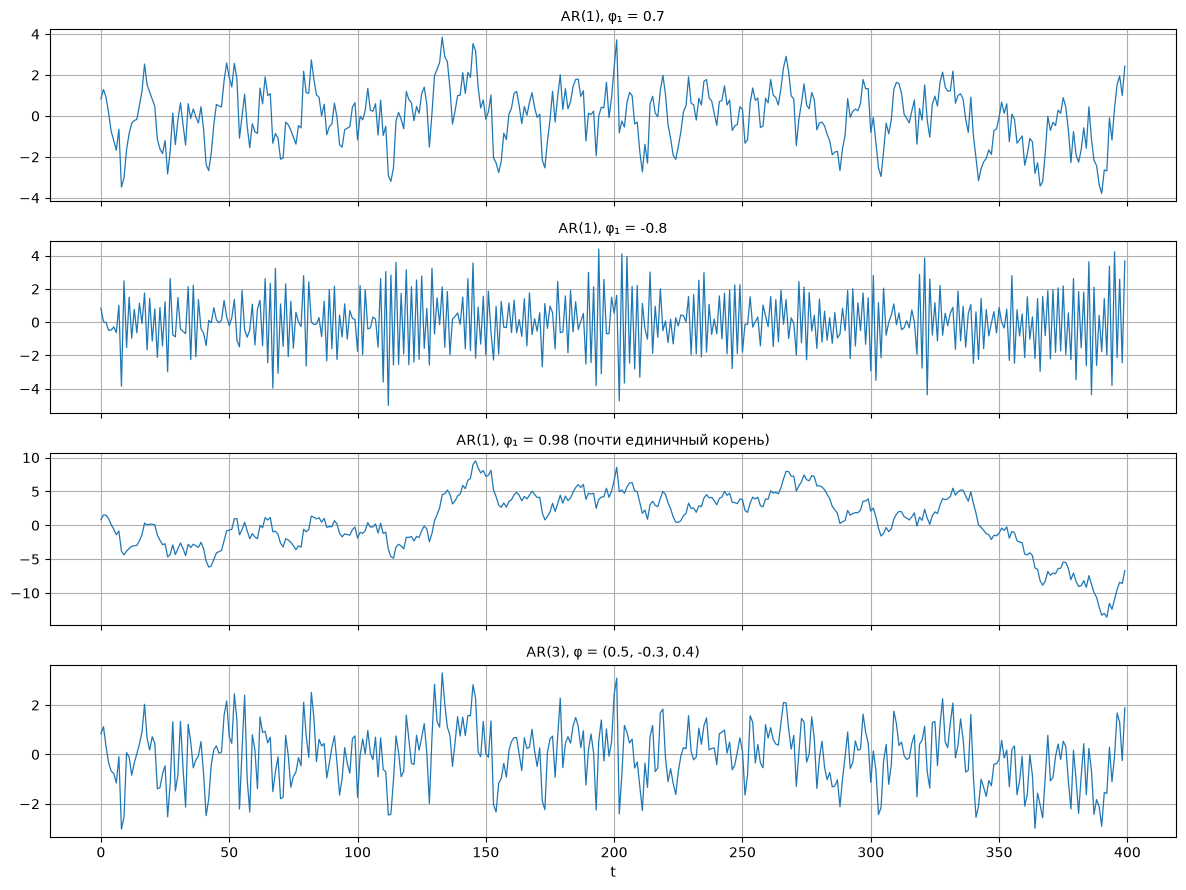

In [17]:
ar_specs = {
    "AR(1), φ₁ = 0.7": [0.7],
    "AR(1), φ₁ = -0.8": [-0.8],
    "AR(1), φ₁ = 0.98 (почти единичный корень)": [0.98],
    "AR(3), φ = (0.5, -0.3, 0.4)": [0.5, -0.3, 0.4],
}

ar_samples = {}
for name, phis in ar_specs.items():
    process = ArmaProcess.from_coeffs(arcoefs=phis, macoefs=[])
    ar_samples[name] = process.generate_sample(N, distrvs=rng().standard_normal)

fig, axes = plt.subplots(len(ar_samples), 1, figsize=(12, 9), sharex=True)
for ax, (name, y) in zip(axes, ar_samples.items()):
    ax.plot(y, lw=0.9)
    ax.set_title(name, fontsize=10)
axes[-1].set_xlabel("t")
fig.tight_layout()
plt.show()

Здесь разница видна уже на глаз, и это отличает AR от MA:

* $\varphi_1 = 0.7$ — плавные волны: положительный коэффициент тянет ряд в
  ту же сторону, где он был вчера;
* $\varphi_1 = -0.8$ — **пила**: отрицательный коэффициент каждый шаг
  переворачивает знак отклонения. Такой ряд почти всегда означает
  передифференцированные данные;
* $\varphi_1 = 0.98$ — ряд визуально неотличим от случайного блуждания,
  хотя формально стационарен. Ровно этот случай губил мощность ADF в
  ноутбуке `1.02`;
* AR(3) — смесь всех эффектов.

🔍 Пример с $\varphi_1 = -0.8$ в русскоязычных лекциях часто выпадает, и
зря: без него студенты запоминают, что «AR — это плавно», и не узнают
AR-структуру в пилообразном ряду.

## 3.3. Главное свойство: PACF обрывается на лаге $p$

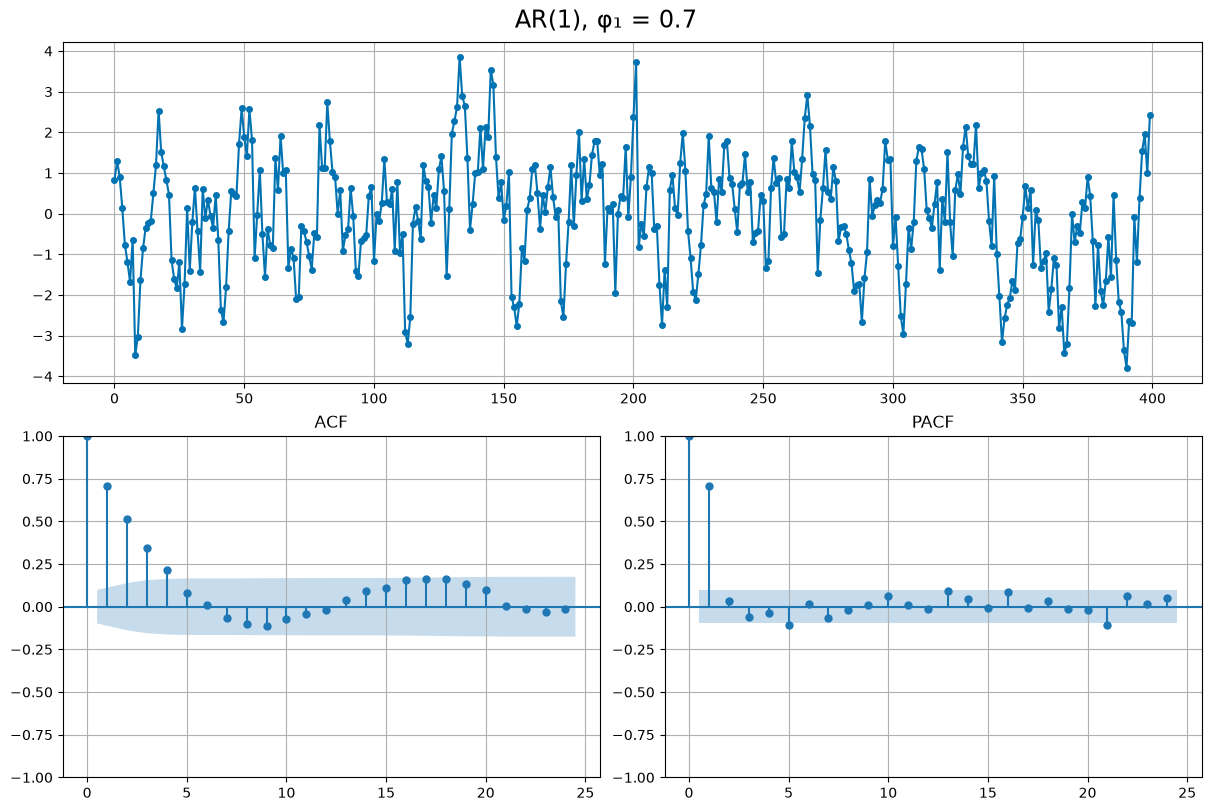

<Figure size 1300x600 with 0 Axes>

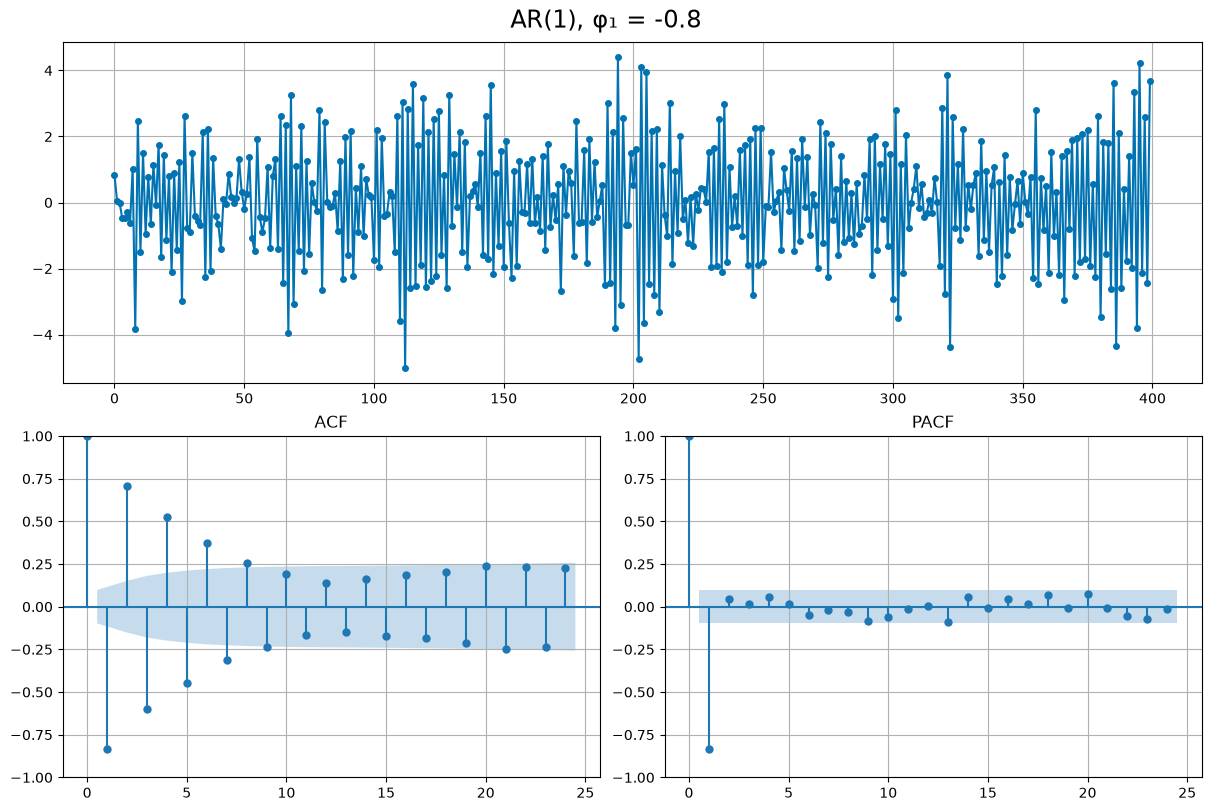

<Figure size 1300x600 with 0 Axes>

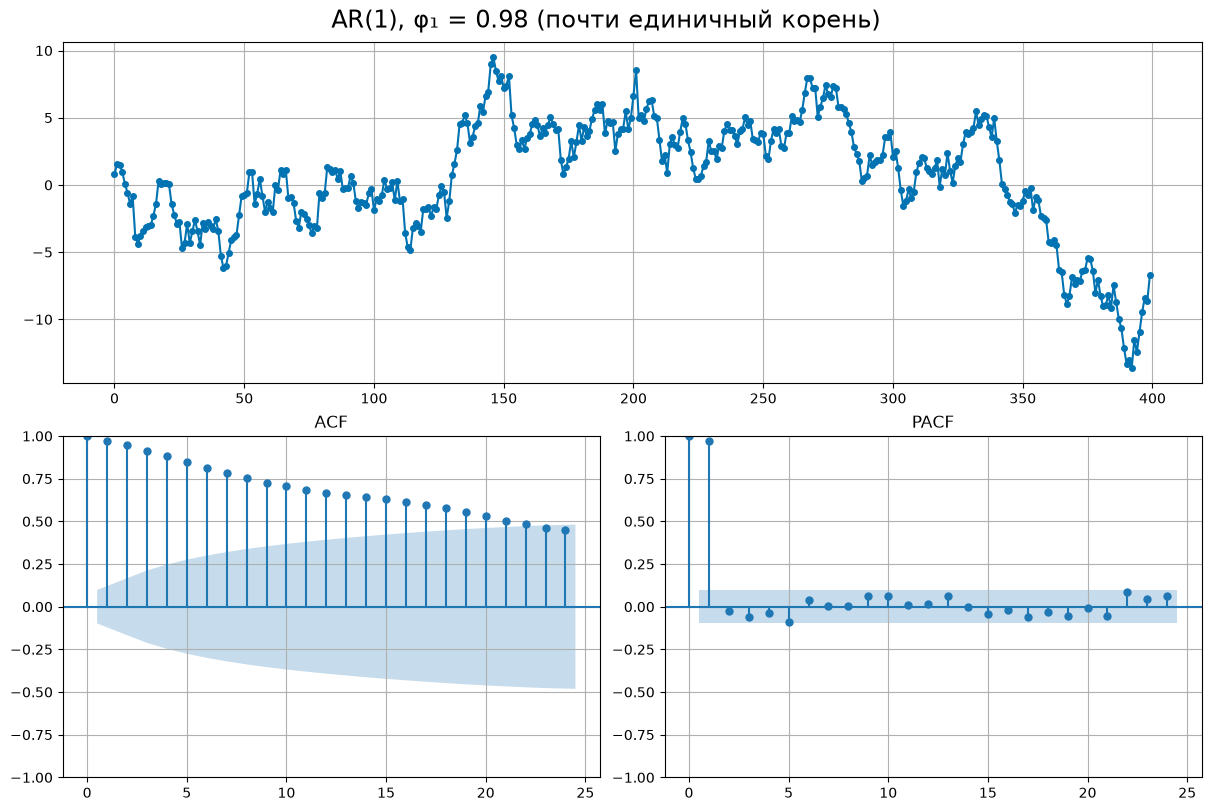

<Figure size 1300x600 with 0 Axes>

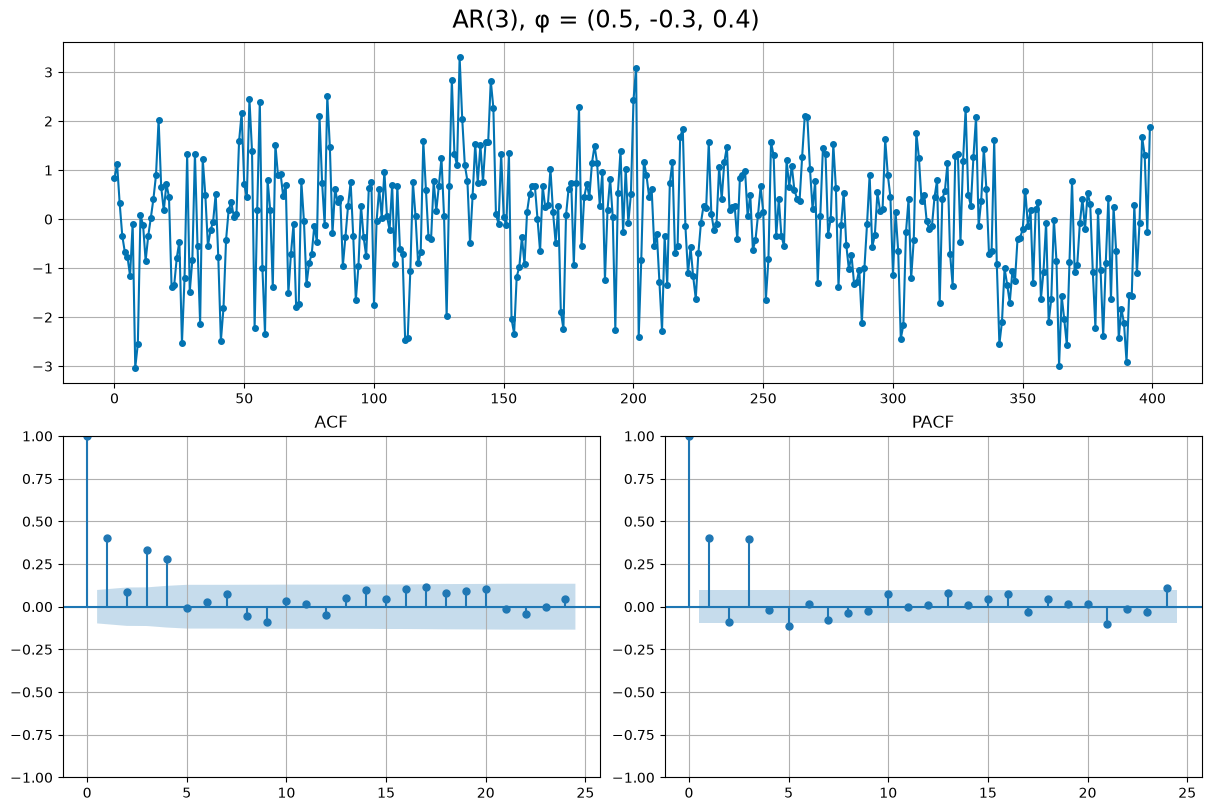

<Figure size 1300x600 with 0 Axes>

In [19]:
for name in ar_samples:
    tsdisplay(pd.Series(ar_samples[name]), lags=24, title=name)
    plt.show()

Картина зеркальная по отношению к MA:

* **ACF затухает** — экспоненциально при $\varphi_1 > 0$, знакопеременно
  при $\varphi_1 < 0$, мучительно медленно при $\varphi_1 = 0.98$;
* **PACF обрывается** ровно на лаге $p$: один столбик у AR(1), три у AR(3).

> 🔑 **Правило идентификации AR.** Если PACF **обрывается** после лага $p$,
> а ACF **затухает** — это AR($p$).

Почему обрывается именно PACF? Частная автокорреляция $\alpha_k$ — это
коэффициент при $y_{t-k}$ в регрессии $y_t$ на $y_{t-1}, \dots, y_{t-k}$,
то есть связь «за вычетом всего, что объясняется промежуточными лагами».
У AR($p$) при $k > p$ такой связи нет по построению: $y_{t-k}$ влияет на
$y_t$ **только через** промежуточные значения. Подробный ручной расчёт
PACF через OLS — в ноутбуке `03`.

## 3.4. Условие стационарности

Возьмём AR(1) и подставим сам в себя $k$ раз:

$$ y_t = \varepsilon_t + \varphi_1 \varepsilon_{t-1} + \varphi_1^2 \varepsilon_{t-2} + \dots $$

Дисперсия этого ряда равна $\sigma^2 \sum_j \varphi_1^{2j}$ — конечна
только при $|\varphi_1| < 1$. При $\varphi_1 = 1$ получается случайное
блуждание с $\mathrm{Var}(y_t) = t\sigma^2$ (ноутбук `1.01`), при
$|\varphi_1| > 1$ ряд взрывается экспоненциально.

В общем случае условие формулируется через корни $\varphi(L)$: **все корни
лежат вне единичного круга**. Для AR(1) корень равен $1/\varphi_1$, и
условие $|1/\varphi_1| > 1$ — это в точности $|\varphi_1| < 1$.

In [20]:
rows = []
for phis in ([0.7], [-0.8], [0.98], [1.0], [1.05], [0.5, -0.3, 0.4], [0.6, 0.5]):
    process = ArmaProcess.from_coeffs(arcoefs=phis, macoefs=[])
    roots = process.arroots
    rows.append(
        {
            "φ": str(phis),
            "|корни| φ(L)": np.round(np.abs(roots), 4),
            "min |корень|": round(np.abs(roots).min(), 4),
            "isstationary": process.isstationary,
        }
    )

pd.DataFrame(rows)

,φ,|корни| φ(L),min |корень|,isstationary
0,[0.7],[1.4286],1.4286,True
1,[-0.8],[1.25],1.2500,True
2,[0.98],[1.0204],1.0204,True
3,[1.0],[1.0],1.0000,False
4,[1.05],[0.9524],0.9524,False
5,"[0.5, -0.3, 0.4]","[1.3935, 1.3935, 1.2874]",1.2874,True
6,"[0.6, 0.5]","[2.1362, 0.9362]",0.9362,False


Обратите внимание на последнюю строку: AR(2) с $\varphi_1 + \varphi_2 = 1.1$
нестационарен, хотя оба коэффициента по модулю меньше единицы. Проверять
«каждый $\varphi_i$ по модулю меньше 1» — **неверно**; смотреть нужно на
корни.

🔍 Практическое следствие, которое пригодится в ноутбуке `03`: если у
оценённой модели $\hat\varphi_1 + \dots + \hat\varphi_p \approx 1$, значит
у $\varphi(L)$ корень около единицы, и настоящее лечение — увеличить $d$,
а не наращивать $p$.

---


# 4. MA($\infty$) и AR($\infty$): два языка для одного процесса

Мы уже дважды натыкались на одно и то же: «AR разворачивается в
бесконечное MA», «MA разворачивается в бесконечное AR». Пора посмотреть на
коэффициенты этих разложений.

## 4.1. AR(1) как MA($\infty$)

$$ y_t = \varphi_1 y_{t-1} + \varepsilon_t
   \;\Rightarrow\;
   y_t = \sum_{j \ge 0} \varphi_1^{\,j}\, \varepsilon_{t-j}. $$

Веса $\psi_j = \varphi_1^j$ убывают геометрически. Функция `arma2ma`
считает их численно.

In [29]:
psi = arma2ma(ar=np.r_[1, -0.7], ma=np.r_[1], lags=8)

pd.DataFrame(
    {"ψⱼ из arma2ma": psi, "формула φ₁ʲ = 0.7ʲ": 0.7 ** np.arange(8)},
    index=pd.RangeIndex(0, 8, name="j"),
).round(6)

,ψⱼ из arma2ma,формула φ₁ʲ = 0.7ʲ
j,,
0,1.000000,1.000000
1,0.700000,0.700000
2,0.490000,0.490000
3,0.343000,0.343000
4,0.240100,0.240100
5,0.168070,0.168070
6,0.117649,0.117649
7,0.082354,0.082354


Совпадение точное. Именно эти $\psi_j$ понадобятся в ноутбуке `02` для
расчёта интервалов прогноза: дисперсия $h$-шагового прогноза выражается
ровно через них.

## 4.2. MA(1) как AR($\infty$)

Обратное разложение мы уже выписывали руками в разделе 2.2:
$\varepsilon_t = y_t - \theta_1 y_{t-1} + \theta_1^2 y_{t-2} - \dots$

In [30]:
pi_coefs = arma2ar(ar=np.r_[1], ma=np.r_[1, 0.6], lags=8)

pd.DataFrame(
    {"коэффициенты из arma2ar": pi_coefs, "формула (−θ₁)ʲ = (−0.6)ʲ": (-0.6) ** np.arange(8)},
    index=pd.RangeIndex(0, 8, name="j"),
).round(6)

,коэффициенты из arma2ar,формула (−θ₁)ʲ = (−0.6)ʲ
j,,
0,1.000000,1.000000
1,-0.600000,-0.600000
2,0.360000,0.360000
3,-0.216000,-0.216000
4,0.129600,0.129600
5,-0.077760,-0.077760
6,0.046656,0.046656
7,-0.027994,-0.027994


🔍 `arma2ar` возвращает коэффициенты **лаг-многочлена** $\pi(L)$, то есть
уравнение читается как $\sum_j \pi_j y_{t-j} = \varepsilon_t$. Знаки в
уравнении для $y_t$ будут противоположными — та же ловушка со знаками,
что и у `ar` в конструкторе.

Сравним скорость затухания у обратимого и необратимого MA(1).

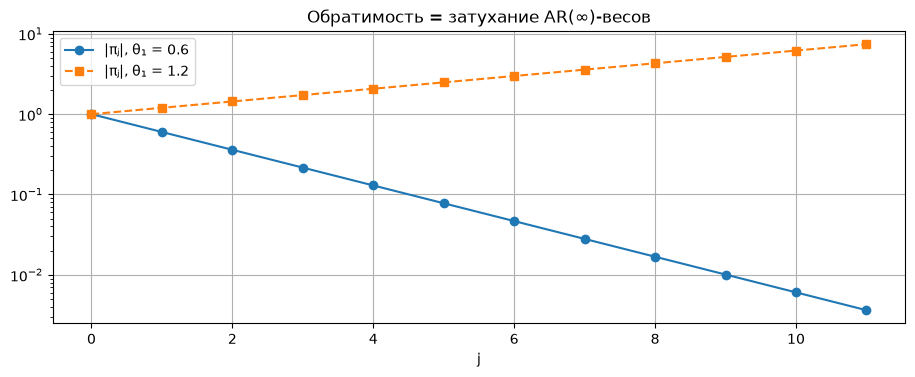

In [31]:
fig, ax = plt.subplots(figsize=(11, 3.8))
for th, style in [(0.6, "o-"), (1.2, "s--")]:
    coefs = arma2ar(ar=np.r_[1], ma=np.r_[1, th], lags=12)
    ax.plot(np.arange(12), np.abs(coefs), style, label=f"|πⱼ|, θ₁ = {th}")
ax.set_yscale("log")
ax.set_xlabel("j")
ax.set_title("Обратимость = затухание AR(∞)-весов")
ax.legend()
plt.show()

При $\theta_1 = 0.6$ веса падают экспоненциально — прошлое быстро
перестаёт влиять. При $\theta_1 = 1.2$ они экспоненциально **растут**:
формально ряд для $\varepsilon_t$ расходится, и модель непригодна для
рекурсивного прогноза. Вот наглядное содержание слова «обратимость».

## 4.3. Мостик к семинару 3: SES — это MA($\infty$)-веса

Простое экспоненциальное сглаживание из семинара 3 давало прогноз

$$ \hat{y}_{T+1} = \alpha y_T + \alpha(1-\alpha) y_{T-1} + \alpha(1-\alpha)^2 y_{T-2} + \dots $$

— геометрически убывающие веса на прошлых наблюдениях. Это ровно та же
конструкция, что и AR($\infty$)-разложение. Совпадение не случайно:
**ARIMA(0,1,1) алгебраически эквивалентна ETS(A,N,N)** при
$\theta_1 = \alpha - 1$. Проверим соответствие весов численно.

ARIMA(0,1,1) — это $(1 - L)\, y_t = (1 + \theta_1 L)\,\varepsilon_t$, поэтому
в `arma2ar` надо передать AR-многочлен разности: `ar = [1, -1]`. Результат —
коэффициенты $\pi(L)$ из записи $\sum_j \pi_j y_{t-j} = \varepsilon_t$, а
веса при прошлых наблюдениях в уравнении для $y_t$ — это $-\pi_j$.

In [32]:
alpha = 0.3
theta_equiv = alpha - 1  # = -0.7

pi_arima = arma2ar(ar=np.r_[1, -1], ma=np.r_[1, theta_equiv], lags=9)

pd.DataFrame(
    {
        "веса SES: α(1−α)ʲ": alpha * (1 - alpha) ** np.arange(8),
        "−πⱼ₊₁ из ARIMA(0,1,1)": -pi_arima[1:9],
    },
    index=pd.RangeIndex(0, 8, name="j"),
).round(6)

,веса SES: α(1−α)ʲ,"−πⱼ₊₁ из ARIMA(0,1,1)"
j,,
0,0.300000,0.300000
1,0.210000,0.210000
2,0.147000,0.147000
3,0.102900,0.102900
4,0.072030,0.072030
5,0.050421,0.050421
6,0.035295,0.035295
7,0.024706,0.024706


Числа совпадают до последнего знака: прогноз ARIMA(0,1,1) — это в точности
экспоненциально взвешенное среднее прошлых наблюдений с параметром
$\alpha = 1 + \theta_1$. Полный разбор соответствий ARIMA ↔ ETS (включая
ARIMA(0,2,2) ≡ ETS(A,A,N) и ARIMA(1,1,2) ≡ ETS(A,A$_d$,N)) — в ноутбуке
`05`. Здесь важно другое: **AR и MA не два разных мира, а две разные
параметризации одного и того же семейства**. Выбирают ту, где параметров
меньше.

---
# 5. ARMA($p$, $q$): когда не обрывается ничего

$$ y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p}
         + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}. $$

Зачем нужна смешанная модель, если AR($\infty$) и MA($\infty$) и так
универсальны? Ради **экономии параметров**: ARMA(1,1) с двумя числами
описывает то, для чего чистому AR понадобилось бы 5–10 коэффициентов.

Диагностическая цена этой экономии высока, и её надо знать заранее.

ARMA(1,1): φ = 0.7, θ = 0.6: стационарен = True, обратим = True


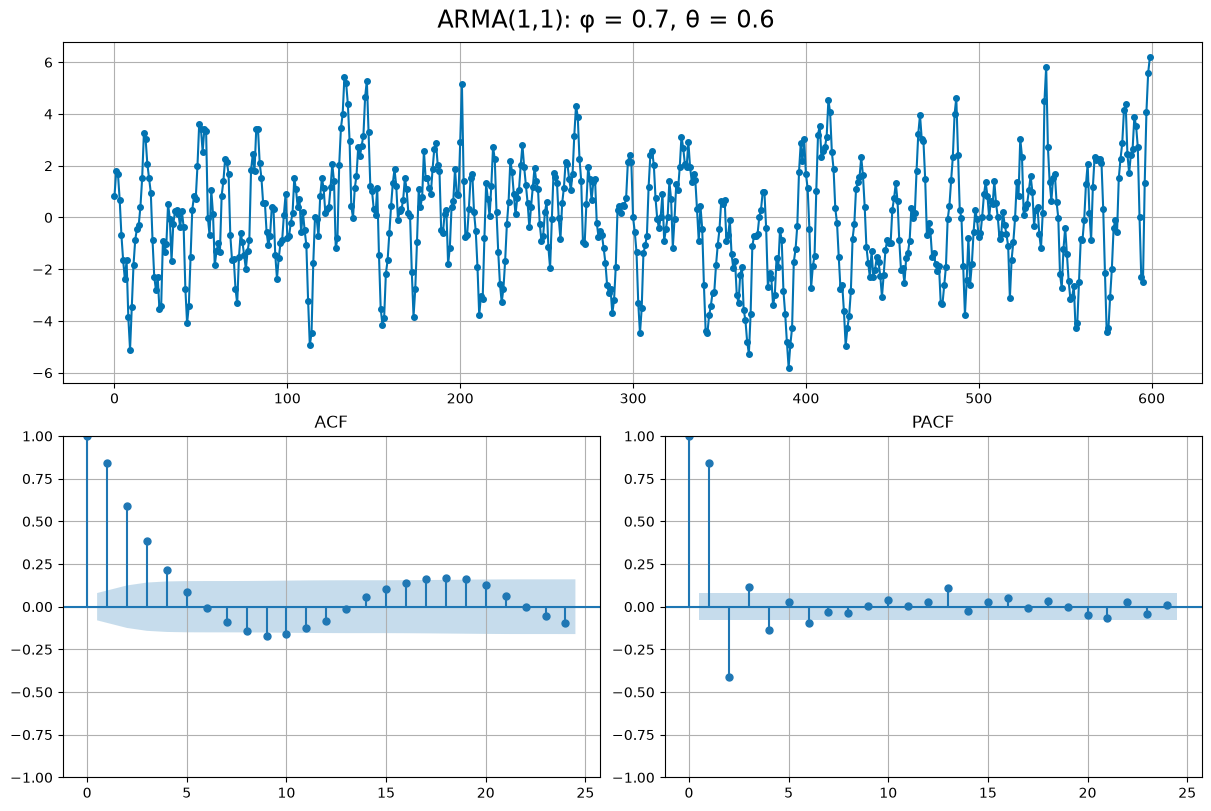

<Figure size 1300x600 with 0 Axes>

ARMA(3,3): стационарен = True, обратим = True


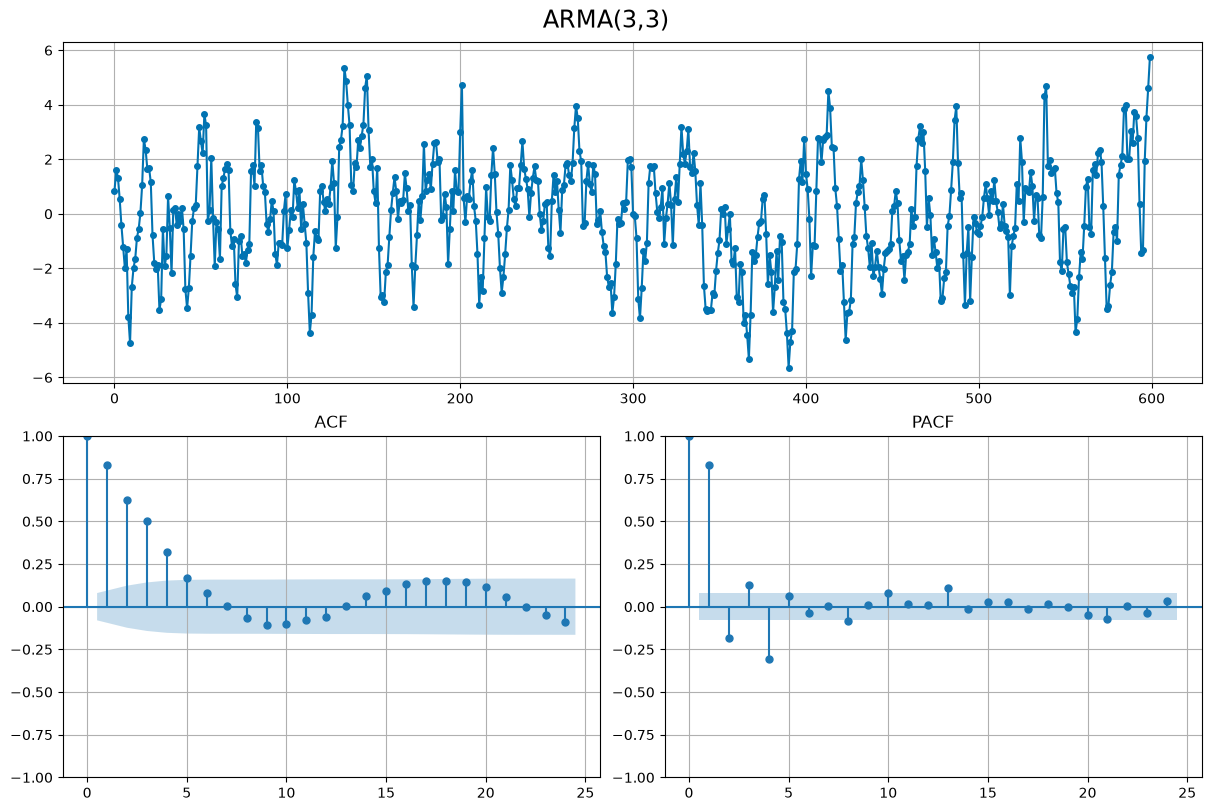

<Figure size 1300x600 with 0 Axes>

In [34]:
arma_specs = {
    "ARMA(1,1): φ = 0.7, θ = 0.6": ([0.7], [0.6]),
    "ARMA(3,3)": ([0.5, -0.3, 0.4], [0.6, 0.4, 0.3]),
}

for name, (phis, thetas) in arma_specs.items():
    process = ArmaProcess.from_coeffs(arcoefs=phis, macoefs=thetas)
    y = process.generate_sample(600, distrvs=rng().standard_normal)
    print(f"{name}: стационарен = {process.isstationary}, обратим = {process.isinvertible}")
    tsdisplay(pd.Series(y), lags=24, title=name)
    plt.show()

> 🔑 **Правило идентификации ARMA (от противного).** Если **ни ACF, ни
> PACF не обрываются**, а обе затухают — это ARMA. Определить $p$ и $q$
> по картинке при этом **нельзя**; их подбирают перебором по
> информационному критерию (ноутбук `03`).

Соберём три правила в одну шпаргалку — к ней мы будем возвращаться весь
оставшийся семинар.

In [35]:
pd.DataFrame(
    [
        ["затухает", "обрывается после лага p", "p — по PACF"],
        ["обрывается после лага q", "затухает", "q — по ACF"],
        ["затухает", "затухает", "перебор по AICc"],
        ["всё внутри полос", "всё внутри полос", "моделировать нечего"],
    ],
    columns=["ACF", "PACF", "как определить порядок"],
    index=pd.Index(["AR(p)", "MA(q)", "ARMA(p,q)", "белый шум"], name="процесс"),
)

,ACF,PACF,как определить порядок
процесс,,,
AR(p),затухает,обрывается после лага p,p — по PACF
MA(q),обрывается после лага q,затухает,q — по ACF
"ARMA(p,q)",затухает,затухает,перебор по AICc
белый шум,всё внутри полос,всё внутри полос,моделировать нечего


🔍 **Правило 8 (лонгрид): избегайте смешанных моделей без нужды.**
У ARMA есть неприятное свойство — AR- и MA-части могут почти сокращаться.
Посмотрим на ARMA(1,1) с $\varphi_1 = 0.7$ и $\theta_1 = -0.7$: множители
$(1 - 0.7L)$ и $(1 - 0.7L)$ стоят по разные стороны уравнения и гасят друг
друга.

In [36]:
y_cancel = ArmaProcess.from_coeffs([0.7], [-0.7]).generate_sample(1000, distrvs=rng().standard_normal)

fit_arma = ARIMA(y_cancel, order=(1, 0, 1), trend="n").fit()
fit_wn = ARIMA(y_cancel, order=(0, 0, 0), trend="n").fit()

print(fit_arma.summary().tables[1])
print(f"\nAIC ARMA(1,1): {fit_arma.aic:8.2f}")
print(f"AIC белый шум: {fit_wn.aic:8.2f}")
print("выборочная ACF на лагах 1–3:", np.round(sm.tsa.acf(y_cancel, nlags=3)[1:], 4))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6158      1.198      0.514      0.607      -1.731       2.963
ma.L1         -0.6021      1.214     -0.496      0.620      -2.981       1.777
sigma2         1.0283      0.045     22.709      0.000       0.940       1.117

AIC ARMA(1,1):  2871.76
AIC белый шум:  2868.06
выборочная ACF на лагах 1–3: [-0.0138  0.0512  0.0385]


Ряд статистически неотличим от белого шума: ACF пуста, а лишняя ARMA(1,1)
проигрывает по AIC. При этом оценки $\hat\varphi_1$ и $\hat\theta_1$ имеют
огромные стандартные ошибки — оптимизатору всё равно, какую пару чисел
выбрать, лишь бы они сокращались. Такой «плоский» ландшафт правдоподобия —
типичный симптом переусложнённой смешанной модели.

---
# 6. Роль константы: почему `const` — это не $c$

Одно и то же ARMA можно записать двумя способами.

**Форма с интерсептом** (та, что стоит в определении):

$$ y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p} + \varepsilon_t. $$

**Форма со средним** (отклонения от уровня):

$$ (y_t - \mu) = \varphi_1 (y_{t-1} - \mu) + \dots + \varphi_p (y_{t-p} - \mu) + \varepsilon_t. $$

Раскрыв скобки, получаем связь:

$$ \boxed{\,c = \mu\,(1 - \varphi_1 - \dots - \varphi_p)\,} $$

Отсюда вечный вопрос на семинарах: «почему `const` в `summary()` не похож
ни на что осмысленное?» Ответ зависит от того, какую форму печатает
библиотека. Проверим на ряде с заведомо известным средним $\mu = 10$.

In [37]:
mu_true, phi_true = 10.0, 0.7
y_mean = mu_true + ArmaProcess.from_coeffs([phi_true], []).generate_sample(1000, distrvs=rng().standard_normal)

fit_c = ARIMA(y_mean, order=(1, 0, 0), trend="c").fit()
print(fit_c.summary().tables[1])

mu_hat, phi_hat = fit_c.params[0], fit_c.params[1]
print(f"\nвыборочное среднее ряда      : {y_mean.mean():.4f}")
print(f"'const' из summary()         : {mu_hat:.4f}   ← это μ, а не c")
print(f"интерсепт c = μ(1 − φ₁)      : {mu_hat * (1 - phi_hat):.4f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0555      0.111     90.984      0.000       9.839      10.272
ar.L1          0.7094      0.022     31.675      0.000       0.665       0.753
sigma2         1.0278      0.045     22.730      0.000       0.939       1.116

выборочное среднее ряда      : 10.0522
'const' из summary()         : 10.0555   ← это μ, а не c
интерсепт c = μ(1 − φ₁)      : 2.9223


🔑 **`statsmodels` печатает форму со средним:** `const` $= \hat\mu \approx 10$,
и он действительно близок к среднему ряда. А вот интерсепт $c$ из
уравнения равен примерно $10 \cdot (1 - 0.7) = 3$, и увидеть его в
`summary()` нельзя — его надо посчитать.

🔍 Когда это ловит людей за руку:

* при переносе коэффициентов из `summary()` в уравнение **руками**
  (ровно это мы будем делать в ноутбуке `02`) — подставите $\hat\mu$ вместо
  $c$ и получите неверный прогноз;
* при сравнении с другими библиотеками: часть из них печатает $c$, часть —
  $\mu$ (сравнение библиотек — ноутбук `04`);
* при $d \ge 1$: там `trend="c"` означает уже не средний уровень, а
  **средний наклон** продифференцированного ряда, то есть детерминированный
  тренд в исходном. Это следующий раздел.

Проверим формулу связи «в обе стороны», подогнав ту же модель без
константы на центрированном ряде.

In [38]:
fit_no_c = ARIMA(y_mean - y_mean.mean(), order=(1, 0, 0), trend="n").fit()
print(f"φ₁ с константой на исходном ряде : {fit_c.params[1]:.6f}")
print(f"φ₁ без константы на центрированном: {fit_no_c.params[0]:.6f}")

φ₁ с константой на исходном ряде : 0.709378
φ₁ без константы на центрированном: 0.709377


Оценки $\varphi_1$ практически совпадают: константа и динамика
оцениваются почти независимо. Значит, вычитание среднего — не «другая
модель», а другая параметризация той же.

---
# 7. Как выглядят долгосрочные прогнозы

Последний сюжет ноутбука — что модель говорит о далёком будущем. Точные
формулы разберём в ноутбуке `02`, а сейчас важна качественная картина,
потому что она позволяет **проверить себя глазами**: если долгосрочный
прогноз выглядит не так, как должен для выбранных $p$, $d$, $q$, где-то
ошибка.

## 7.1. Стационарные модели: возврат к среднему

In [39]:
def forecast_picture(y, order, trend, title, h=40, ax=None):
    """Подогнать модель и нарисовать ряд + прогноз на h шагов с интервалом."""
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 3.5))
    res = ARIMA(y, order=order, trend=trend).fit()
    fc = res.get_forecast(h)
    idx = np.arange(len(y), len(y) + h)

    ax.plot(np.arange(len(y)), y, lw=0.8, color="0.35", label="ряд")
    ax.plot(idx, fc.predicted_mean, color="tab:red", lw=2, label="прогноз")
    ci = fc.conf_int()
    ax.fill_between(idx, ci[:, 0], ci[:, 1], color="tab:red", alpha=0.15, label="95% интервал")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    return res

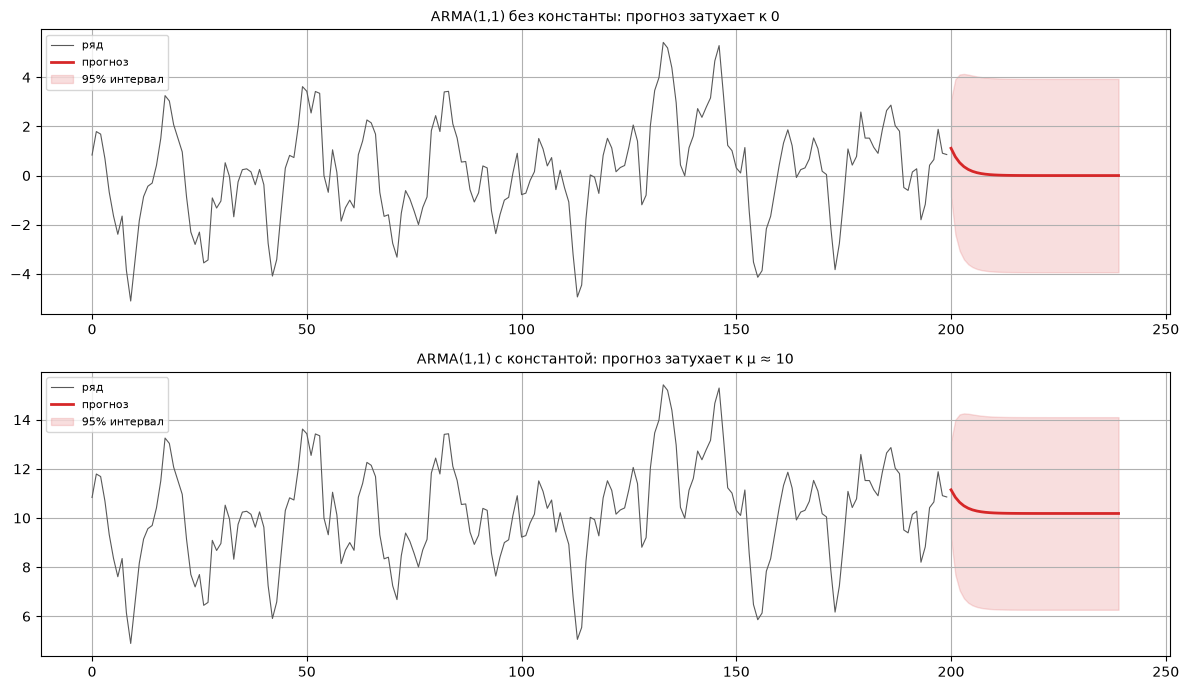

In [40]:
y_ar_zero = ArmaProcess.from_coeffs([0.7], [0.6]).generate_sample(200, distrvs=rng().standard_normal)
y_ar_mean = 10 + y_ar_zero

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
forecast_picture(y_ar_zero, (1, 0, 1), "n", "ARMA(1,1) без константы: прогноз затухает к 0", ax=axes[0])
forecast_picture(y_ar_mean, (1, 0, 1), "c", "ARMA(1,1) с константой: прогноз затухает к μ ≈ 10", ax=axes[1])
fig.tight_layout()
plt.show()

🔑 **У стационарной модели ($d = 0$) долгосрочный прогноз — горизонтальная
прямая на уровне $\mu$**, а интервал выходит на постоянную ширину
$\pm 1.96\,\sigma_y$. Это прямое следствие стационарности: если дисперсия
ряда конечна и постоянна, неопределённость прогноза не может расти вечно.

Скорость выхода на этот уровень задаётся $\varphi_1$: сравним три AR(1).

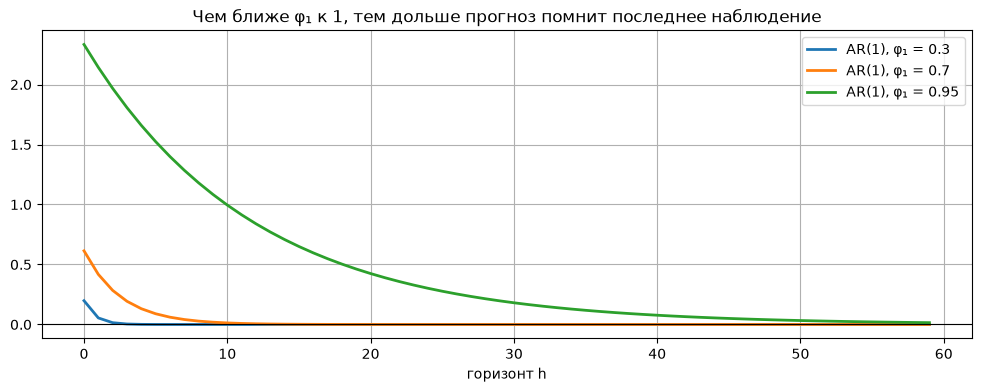

In [41]:
fig, ax = plt.subplots(figsize=(12, 4))
for phi_i in (0.3, 0.7, 0.95):
    y_i = ArmaProcess.from_coeffs([phi_i], []).generate_sample(200, distrvs=rng().standard_normal)
    res = ARIMA(y_i, order=(1, 0, 0), trend="n").fit()
    ax.plot(res.get_forecast(60).predicted_mean, lw=2, label=f"AR(1), φ₁ = {phi_i}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("горизонт h")
ax.set_title("Чем ближе φ₁ к 1, тем дольше прогноз помнит последнее наблюдение")
ax.legend()
plt.show()

## 7.2. Что меняет $d$

При $d \ge 1$ модель перестаёт быть стационарной, и обе картинки меняются
качественно: прогноз больше не возвращается к среднему, а интервал растёт
неограниченно.

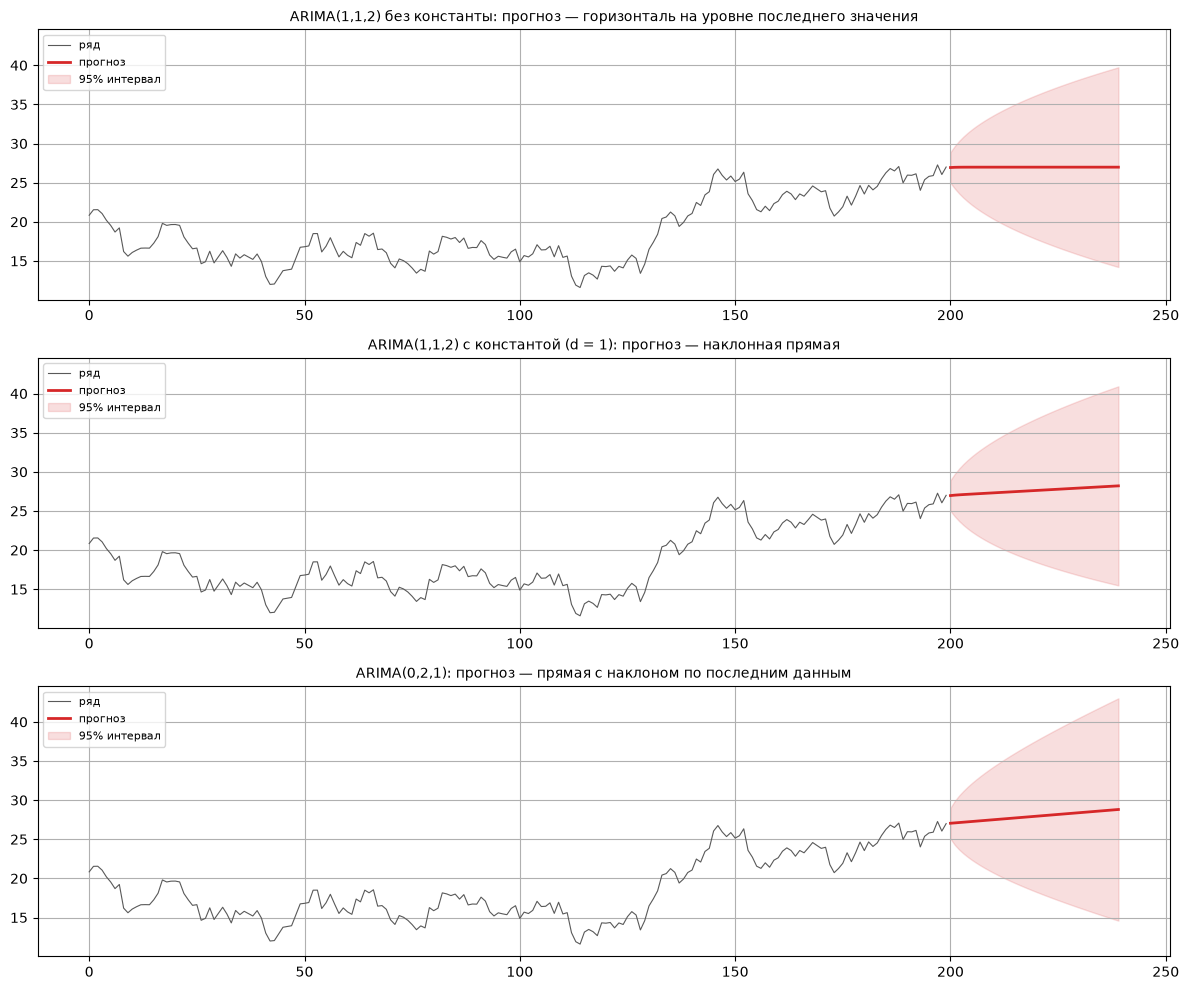

In [42]:
y_walk = np.cumsum(rng().standard_normal(200)) + 20

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True)
forecast_picture(y_walk, (1, 1, 2), "n", "ARIMA(1,1,2) без константы: прогноз — горизонталь на уровне последнего значения", ax=axes[0])
forecast_picture(y_walk, (1, 1, 2), "t", "ARIMA(1,1,2) с константой (d = 1): прогноз — наклонная прямая", ax=axes[1])
forecast_picture(y_walk, (0, 2, 1), "n", "ARIMA(0,2,1): прогноз — прямая с наклоном по последним данным", ax=axes[2])
fig.tight_layout()
plt.show()

Ось $y$ у всех трёх панелей общая, поэтому ширину интервалов можно
сравнивать глазами. Выпишем её явно на нескольких горизонтах.

In [43]:
widths = {}
# Строка «d = 0» здесь — намеренно неправильная модель для этого ряда
# (AR(1) на блуждании). Нас интересует не её качество, а форма интервала.
for label, order, trend in [("d = 0", (1, 0, 0), "c"), ("d = 1", (1, 1, 2), "n"), ("d = 2", (0, 2, 1), "n")]:
    ci = ARIMA(y_walk, order=order, trend=trend).fit().get_forecast(40).conf_int()
    widths[label] = (ci[:, 1] - ci[:, 0])[[0, 4, 9, 19, 39]]

pd.DataFrame(widths, index=pd.Index([1, 5, 10, 20, 40], name="горизонт h")).round(2)

,d = 0,d = 1,d = 2
горизонт h,,,
1,3.90,3.92,3.95
5,8.31,8.78,8.95
10,11.07,12.61,12.88
20,14.00,17.98,18.85
40,16.33,25.52,28.41


Сводка форм долгосрочного прогноза — её удобно держать в голове как
проверку на здравый смысл:

| $d$ | без константы | с константой |
|---|---|---|
| 0 | горизонталь на нуле | горизонталь на уровне $\mu$ |
| 1 | горизонталь на уровне последнего наблюдения | прямая с постоянным наклоном |
| 2 | прямая с наклоном (по последним данным) | парабола |

🔍 Отсюда важное практическое предупреждение (правило 9 лонгрида): при
$d = 2$ **с константой** прогноз растёт квадратично, и на горизонте в
несколько десятков шагов уходит в стратосферу. Поэтому библиотеки по
умолчанию **не включают** константу при $d \ge 2$. Если ваш долгосрочный
прогноз «взорвался» — первым делом проверьте $d$ и наличие тренда.

Обратите внимание и на интервалы: при $d = 0$ их ширина выходит на
константу, при $d = 1$ растёт как $\sqrt{h}$, при $d = 2$ — ещё быстрее.
Численно мы разберём это в ноутбуке `02`.

---
# Итоги

* **Белый шум — сырьё, лаг-многочлены $\varphi(L)$ и $\theta(L)$ — сборка.**
  Почти все свойства процесса — это свойства корней этих двух многочленов
  (раздел 0).
* **MA($q$): память конечная.** ACF обрывается на лаге $q$, PACF затухает.
  У MA(1) первая автокорреляция не превышает 0.5 по модулю (раздел 1).
* **Обратимость MA — это $|\theta_1| < 1$**, то есть корни $\theta(L)$ вне
  единичного круга. Она нужна потому, что $\theta$ и $1/\theta$ дают
  **одинаковую ACF**: без соглашения об обратимости модель не
  идентифицируема. Библиотека всегда вернёт обратимого двойника
  (раздел 2).
* **AR($p$): память бесконечная, но затухающая.** PACF обрывается на лаге
  $p$, ACF затухает. Стационарность — корни $\varphi(L)$ вне единичного
  круга; проверять $|\varphi_i| < 1$ покоэффициентно **нельзя**
  (раздел 3).
* **AR и MA — два языка одного семейства:** AR(1) = MA($\infty$) с весами
  $\varphi^j$, MA(1) = AR($\infty$) с весами $(-\theta)^j$. Отсюда же
  мостик к ETS: ARIMA(0,1,1) ≡ ETS(A,N,N) при $\theta_1 = \alpha - 1$
  (раздел 4).
* **ARMA: не обрывается ничего.** Порядок по картинке не определить —
  только перебором. И осторожнее со смешанными моделями: AR- и MA-части
  умеют почти сокращаться (раздел 5).
* **`const` в `summary()` — это $\mu$, а не интерсепт $c$.** Связь:
  $c = \mu(1 - \varphi_1 - \dots - \varphi_p)$ (раздел 6).
* **Форма долгосрочного прогноза целиком определяется парой ($d$,
  константа)** — от горизонтали до параболы (раздел 7).

## Шпаргалка идентификации

| Что видим на коррелограммах | Вывод |
|---|---|
| ACF обрывается на лаге $q$, PACF затухает | MA($q$) |
| ACF затухает, PACF обрывается на лаге $p$ | AR($p$) |
| обе затухают | ARMA — порядок перебором |
| обе внутри полос | белый шум |
| ACF затухает очень медленно | корень $\approx 1$ ⇒ вернуться к $d$ |
| ACF(1) $\le -0.5$, «пила» | сверхдифференцирование (ноутбук `1.03`) |
